# Profit Concentration — Do a Few Customers Drive the Business?

Follow-up to `Q2_high_value_customers.ipynb`. That notebook fixed the segment size (top 10% by
spend) and asked what they look like. Here we flip the question around: instead of picking a
segment size, we ask **how concentrated profit actually is**, directly:

1. What % of customers account for 50% of total profit?
2. If we split customers into a top and bottom half, what % of profit does each half get?
3. Given that, should we be focusing our attention (retention, account management, targeting)
   on the top slice of customers?

**Setup:** every customer base has *some* concentration — a few big spenders always outweigh a
long tail of small ones. The question isn't whether concentration exists, it's whether it's
severe enough to change how we operate: are we effectively running a business for a small
elite of accounts we can't afford to lose, or is profit spread widely enough that no single
customer (or small group) is a real dependency risk?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["axes.formatter.useoffset"] = False
plt.rcParams["axes.formatter.limits"] = (-999, 999)

PLAIN = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}")
PCT = mticker.FuncFormatter(lambda x, pos: f"{x:,.0f}%")
MILLIONS = mticker.FuncFormatter(lambda x, pos: f"{x/1e6:,.0f}")

df = pd.read_csv("orders.csv", parse_dates=["Order_Date"])
df.shape

(682792, 11)

## 1. Rank customers by profit and build the cumulative (Lorenz) curve

We aggregate to the customer level, sort by total profit **descending**, and track what share
of total profit is accounted for as we accumulate customers from the top down. This cumulative
curve — a Lorenz curve — is the standard way to visualize concentration: the further it bows
away from the diagonal "everyone contributes equally" line, the more concentrated profit is.

In [2]:
cust = df.groupby("Customer_iD").agg(
    n_orders=("Order_ID", "size"),
    total_spend=("Total_amount_excl__VAT", "sum"),
    total_profit=("Profit", "sum"),
).sort_values("total_profit", ascending=False)

n_customers = len(cust)
total_profit = cust["total_profit"].sum()

cust["cum_profit_share"] = cust["total_profit"].cumsum() / total_profit * 100
cust["cum_customer_share"] = np.arange(1, n_customers + 1) / n_customers * 100

print(f"Customers: {n_customers:,}")
print(f"Total profit: {total_profit:,.0f}")
cust.head()

Customers: 577,950
Total profit: 218,397,306


,n_orders,total_spend,total_profit,cum_profit_share,cum_customer_share
Customer_iD,,,,,
1028997,5,45573.66,33377.7454,0.015283,0.000173
1034220,16,54338.94,31031.7650,0.029492,0.000346
1244104,3,40573.23,22030.5902,0.039579,0.000519
1368118,4,22852.27,16888.1699,0.047312,0.000692
1262771,3,27182.84,15785.7380,0.054540,0.000865


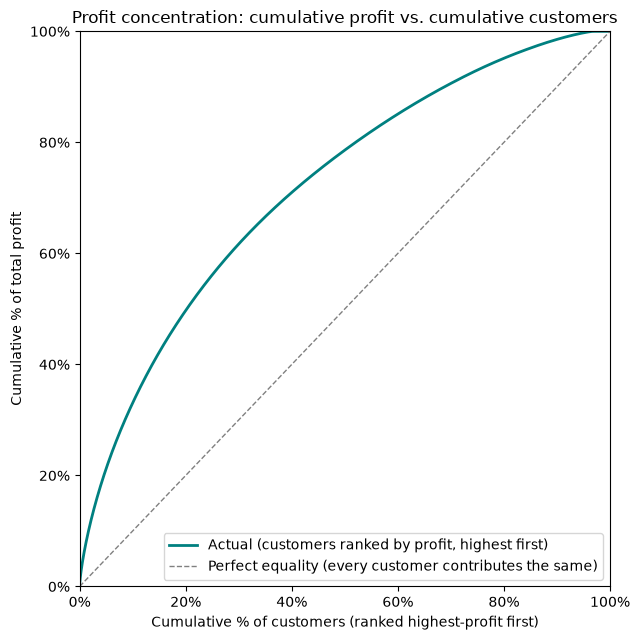

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.plot(cust["cum_customer_share"], cust["cum_profit_share"], color="teal", linewidth=2,
        label="Actual (customers ranked by profit, highest first)")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", linewidth=1,
        label="Perfect equality (every customer contributes the same)")

ax.set_xlabel("Cumulative % of customers (ranked highest-profit first)")
ax.set_ylabel("Cumulative % of total profit")
ax.xaxis.set_major_formatter(PCT)
ax.yaxis.set_major_formatter(PCT)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_title("Profit concentration: cumulative profit vs. cumulative customers")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Conflict:** the curve bows well above the diagonal — a minority of customers clearly account
for a disproportionate share of profit. The two questions from the discovery notes pin down
exactly how disproportionate.

## 2. Answering both halves of the question

**Q3a — what % of customers gives us 50% of profit?**
Read the point on the curve where cumulative profit share crosses 50%.

**Q3b — if we split customers 50/50, what % of profit does the top half get?**
Read the curve at the 50%-of-customers mark instead.

In [4]:
# Q3a: smallest % of (highest-profit) customers needed to reach 50% of total profit
idx_50pct_profit = np.searchsorted(cust["cum_profit_share"].values, 50.0)
pct_customers_for_half_profit = cust["cum_customer_share"].iloc[idx_50pct_profit]
n_customers_for_half_profit = idx_50pct_profit + 1

print(f"{pct_customers_for_half_profit:.1f}% of customers ({n_customers_for_half_profit:,} people) "
      f"generate 50% of total profit.")

# Q3b: profit share of the top 50% vs. bottom 50% of customers (by profit)
half = n_customers // 2
top50_profit_share = cust["total_profit"].iloc[:half].sum() / total_profit * 100
bottom50_profit_share = 100 - top50_profit_share

print(f"Top 50% of customers (by profit) generate {top50_profit_share:.1f}% of total profit.")
print(f"Bottom 50% of customers (by profit) generate {bottom50_profit_share:.1f}% of total profit.")

20.2% of customers (116,791 people) generate 50% of total profit.
Top 50% of customers (by profit) generate 78.6% of total profit.
Bottom 50% of customers (by profit) generate 21.4% of total profit.


In [5]:
thresholds = [0.01, 0.05, 0.10, 0.20, 0.50, 0.80, 1.00]
rows = []
for p in thresholds:
    k = max(1, int(round(n_customers * p)))
    rows.append({
        "% of customers (top, by profit)": p * 100,
        "# customers": k,
        "% of profit captured": cust["total_profit"].iloc[:k].sum() / total_profit * 100,
    })
pareto_table = pd.DataFrame(rows).round(1)
pareto_table

,"% of customers (top, by profit)",# customers,% of profit captured
0,1.0,5780,6.9
1,5.0,28898,21.2
2,10.0,57795,33.1
3,20.0,115590,49.7
4,50.0,288975,78.6
5,80.0,462360,95.1
6,100.0,577950,100.0


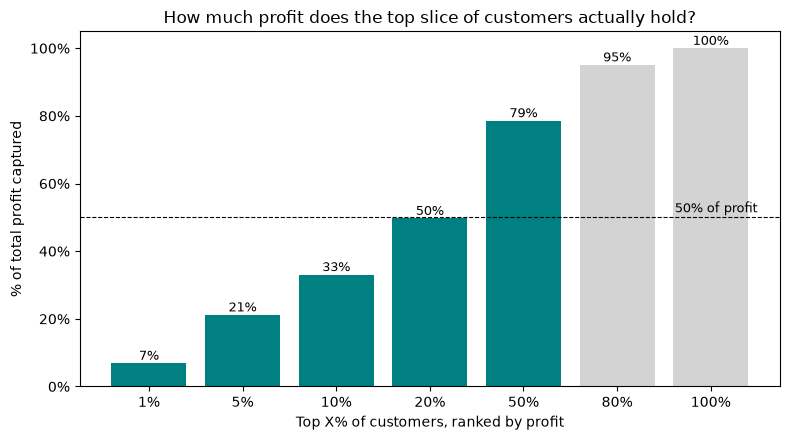

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [f"{p:.0f}%" for p in pareto_table["% of customers (top, by profit)"]]
vals = pareto_table["% of profit captured"]
colors = ["teal" if p <= 50 else "lightgray" for p in pareto_table["% of customers (top, by profit)"]]

bars = ax.bar(labels, vals, color=colors)
ax.axhline(50, color="black", linewidth=0.8, linestyle="--")
ax.text(len(labels) - 0.5, 51.5, "50% of profit", ha="right", fontsize=9)
ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Top X% of customers, ranked by profit")
ax.set_ylabel("% of total profit captured")
ax.set_title("How much profit does the top slice of customers actually hold?")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

## 3. How concentrated is this, really? (Gini coefficient)

The Lorenz curve's shape can be summarized in a single number: the **Gini coefficient** — twice
the area between the curve and the diagonal. 0 = perfectly even (every customer contributes the
same profit), 1 = maximally concentrated (one customer has all the profit). This gives us a
frame of reference: is this a mild, ordinary skew, or a "whale-dependent" business?

In [7]:
sorted_asc = cust["total_profit"].sort_values().values
cum = np.insert(np.cumsum(sorted_asc), 0, 0)
lorenz = cum / cum[-1]
x = np.linspace(0, 1, n_customers + 1)
gini = 1 - 2 * np.trapezoid(lorenz, x)

print(f"Gini coefficient of customer profit: {gini:.3f}")

Gini coefficient of customer profit: 0.437


A Gini of ~0.44 sits in the "moderate concentration" range — noticeably uneven, but nowhere
near the 0.8+ seen in businesses that live or die on a handful of whale accounts. The top 1% of
customers hold only ~7% of profit (see the table above), so no small group of individual
customers is an existential dependency.

## Summary

**Setup:** every customer base has some concentration; the question is whether ours is severe
enough to justify reorganizing how we operate around a top slice of customers.

**Conflict / findings:**
- **~20% of customers generate 50% of total profit** — noticeably faster than an even split, but
  well short of a classic "1% drives everything" whale pattern.
- **Split customers 50/50 by profit and the top half holds ~79% of profit**, the bottom half only
  ~21%. The long tail isn't worthless, but it's clearly the minor contributor.
- **Gini ≈ 0.44** — real, moderate concentration. The top 1% of customers hold only ~7% of
  profit and the top 10% hold ~33%, consistent with what `Q2_high_value_customers.ipynb` found
  for revenue/profit share of the top-10%-by-spend segment (~32%). Concentration here comes from
  a smooth, wide gradient of basket sizes (per Q2: HV customers order the same margin, just
  bigger baskets), not from a handful of exceptional accounts.

**Resolution — should we focus on the top part of our customers?**
Yes, but as a matter of *proportional* attention, not exclusive focus:
- The top ~20% is large enough (100k+ customers here) and profit-dense enough (50% of profit) to
  justify dedicated retention/account-management effort — losing this slice would be a real
  profit hit, and per Q2 they aren't identifiable by timing or loyalty signals, only basket size,
  so spend-based segmentation is the right targeting lever.
- But the bottom 50% of customers still deliver ~21% of profit — too large to ignore or
  deprioritize outright. Because concentration is gradual (Gini 0.44, not a whale pattern), a
  scalable/low-touch strategy (broad free-shipping incentives, automated upsell) is more
  appropriate for that base than high-touch account management, which doesn't scale to hundreds
  of thousands of customers anyway.
- **Action:** prioritize high-touch retention and upsell investment on the top ~20% of customers
  by spend/profit, while keeping broad, low-cost growth levers (e.g. the free-shipping
  conversion strategy from `Q1.1_free_shipping_customer_impact.ipynb`) running for everyone else
  — don't defund the long tail, since it's still a fifth of total profit.